In [409]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings for python figures
plt.style.use('classic')

# plt.rcParams.update({
#     "text.usetex": True,
#     'text.latex.preamble': r'''
#     \usepackage[T1]{fontenc}
#     \usepackage{lmodern}
#     \usepackage[utf8]{inputenc}
#     \usepackage{amsmath}
#     \usepackage{amssymb}
#     \usepackage{siunitx}
#     \usepackage{sfmath}
#     '''
# })
plt.rcParams.update({
    # Figure settings
    'figure.dpi': 150,
    'figure.figsize': (10/2.54, 6/2.54),  # 10x6 cm in inches (1 figure per line)
    # 'figure.figsize': (8/2.54, 6/2.54),  # 10x6 cm in inches (2 figures per line)
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'axes.labelcolor': 'black',
    'savefig.facecolor': 'white',
    'font.family': 'sans-serif',
    'font.sans-serif': 'Arial',
    # 'mathtext.fontset': 'cm',
    'figure.constrained_layout.use': True,

    # Ticks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.major.width": 1,
    "ytick.major.width": 1,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.minor.size": 0,
    "ytick.minor.size": 0,
    "xtick.minor.width":0,
    "ytick.minor.width": 0,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,  

    # Legend
    'legend.frameon': False,
    'legend.title_fontsize': 8,
    'legend.fontsize': 8,
    'legend.handlelength': 2,
    'legend.loc': 'best',
    'legend.numpoints': 1,

    # Line style
    'lines.linestyle': '-',
    'lines.linewidth': 1,
    'lines.markersize': 4,
    'lines.markeredgecolor': 'white',
    'lines.markeredgewidth': 0.5,
})


In [410]:
data = np.loadtxt("./Data-Mani/003.dat")
# data = np.loadtxt("./Data-Mani/023.dat")
# data = np.loadtxt("./Data-20262306/31.dat")

V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_C = 0.5 * (data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = -data[:, 7]
V_del = -(V_GS - V_C)

# plt.plot(
#     V_del,
#     sigma * 1e6,
#     color='red',
#     marker='o',
#     markevery=1,
#     ls='-',
#     markeredgecolor="white", markeredgewidth=1, markersize=7
#     )

# plt.xlabel(r"$V_{GS} - V_C$ (V)")
# plt.ylabel(r"$\sigma$ ($\mu$S/sq.)")
# plt.title("Conductivity vs. Gate Voltage")
# plt.show()

C = 2e-9
A = 32e-6
Ci = C / A

Mobility ($\mu$): 3.10 cm^2/Vs
Threshold Voltage ($V_T$): 10.11 V


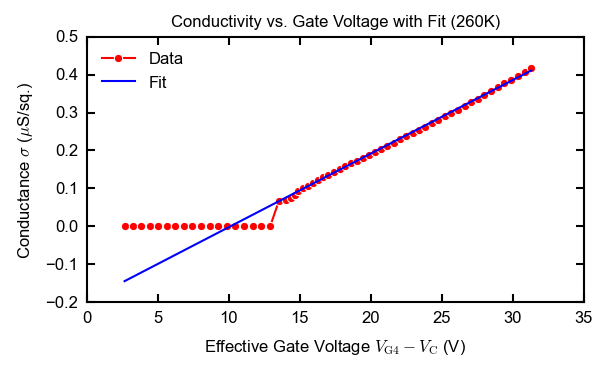

In [411]:
def func(x, a, b):
    return a*x + b

mask = (V_del > 15) & (V_del < 100)


popt, pcov = curve_fit(func, V_del[mask], sigma[mask])
sigma_fit = func(V_del, *popt)
a = popt[0]
b = popt[1]

mu = a / Ci * 1e4
V_T = -b / a

print(rf"Mobility ($\mu$): {mu:.2f} cm^2/Vs")
print(rf"Threshold Voltage ($V_T$): {V_T:.2f} V")



# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))

plt.plot(
    V_del,
    sigma * 1e6,
    color='red',
    marker='o',
    markevery=1,
    ls='-',
    label='Data',
    )
plt.plot(
    V_del,
    sigma_fit * 1e6,
    color='blue',
    ls='-',
    label=f'Fit'
    )
plt.xlabel(r"Effective Gate Voltage $V_{\mathrm{G4}} - V_\mathrm{C}$ (V)")
plt.ylabel(r"Conductance $\sigma$ ($\mu$S/sq.)")
plt.title("Conductivity vs. Gate Voltage with Fit (260K)")
# plt.xlim(10,40)
# plt.ylim(0, 0.0001)  # Convert to μS/sq. for y-axis limits
plt.legend()
# plt.savefig("sigma_cold.eps", format = 'eps')
plt.show()




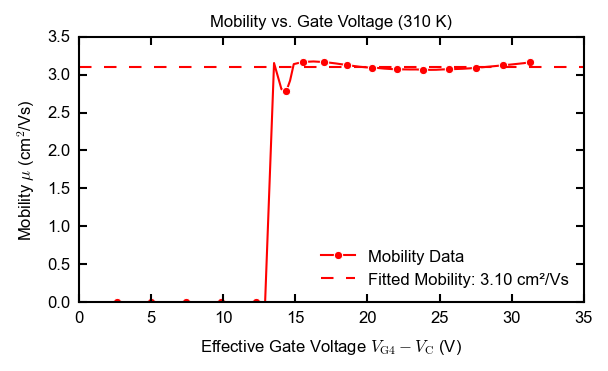

In [412]:
mu_var = sigma/Ci/(V_del - V_T) * 1e4

plt.plot(
    V_del,
    mu_var,
    color='red',
    marker='o',
    markevery=4,
    label='Mobility Data'
    )

plt.axhline(mu, color='red', ls='--', label=f'Fitted Mobility: {mu:.2f} cm²/Vs')

plt.xlabel(r"Effective Gate Voltage $V_{\mathrm{G4}} - V_\mathrm{C}$ (V)")
plt.ylabel(r"Mobility $\mu$ (cm$^2$/Vs)")
plt.title("Mobility vs. Gate Voltage (310 K)")
# plt.xlim(25, 40)
# plt.ylim(0, 2)
plt.legend(numpoints=1)
# plt.savefig("mu_cold.eps", format = 'eps')
plt.show()



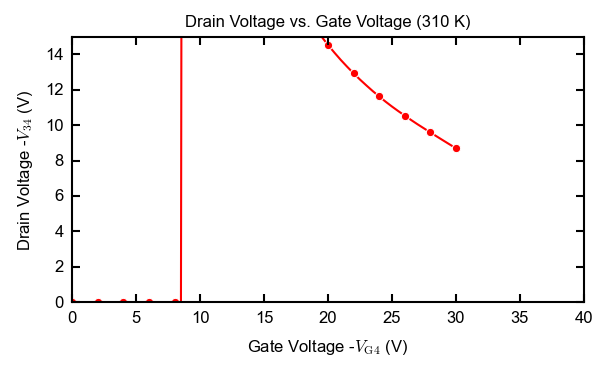

In [413]:
plt.plot(
    -V_GS,
    -V_DS,
    color='red',
    marker='o',
    markevery=4,
    label='V34'
    )


plt.xlabel(r"Gate Voltage -$V_{\mathrm{G4}}$ (V)")
plt.ylabel(r"Drain Voltage -$V_{\mathrm{34}}$ (V)")
plt.title("Drain Voltage vs. Gate Voltage (310 K)")
plt.xlim(0, 40)
plt.ylim(0,15)
# plt.legend()
# plt.savefig("V34_cold.eps", format = 'eps')
plt.show()

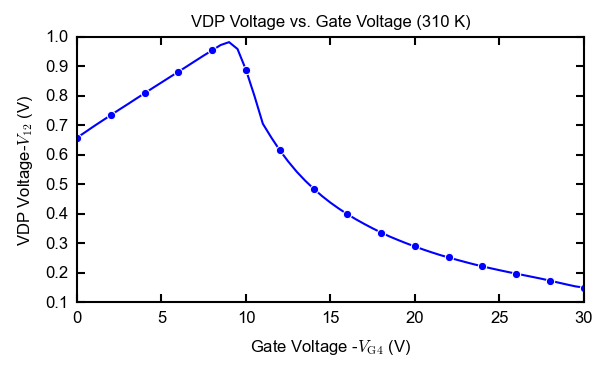

In [414]:
plt.plot(
    -V_GS,
    V_12,
    color='blue',
    marker='o',
    markevery=4,
    label='V12'
    )


plt.xlabel(r"Gate Voltage -$V_\mathrm{G4}$ (V)")
plt.ylabel(r"VDP Voltage-$V_\mathrm{12}$ (V)")
plt.title("VDP Voltage vs. Gate Voltage (310 K)")
# plt.xlim(22, 40)
# plt.ylim(0,0.1)
# plt.legend()
# plt.savefig("V12_cold.eps", format = 'eps')
plt.show()